In [1]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz -O edges2shoes.tar.gz

--2026-02-22 13:29:46--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2165283376 (2.0G) [application/x-gzip]
Saving to: ‘edges2shoes.tar.gz’

edges2shoes.tar.gz  100%[===================>]   2.02G  7.22MB/s    in 6m 46s  

2026-02-22 13:36:32 (5.09 MB/s) - ‘edges2shoes.tar.gz’ saved [2165283376/2165283376]



In [2]:
import tarfile
import os

os.makedirs("mini_edges2shoes/train", exist_ok=True)

tar = tarfile.open("edges2shoes.tar.gz")

count = 0

for member in tar.getmembers():

    if "train/" in member.name and member.name.endswith(".jpg"):

        tar.extract(member, "temp_extract")

        src = os.path.join("temp_extract", member.name)
        dst = os.path.join("mini_edges2shoes/train", f"{count}.jpg")

        os.rename(src, dst)

        count += 1

        if count >= 200:
            break

tar.close()

print("Extracted images:", count)

Extracted images: 200


/tmp/ipython-input-1514694807.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, "temp_extract")


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
class Edges2ShoesDataset(Dataset):

    def __init__(self, root_dir):

        self.root_dir = root_dir
        self.files = os.listdir(root_dir)

        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        img = Image.open(os.path.join(self.root_dir, self.files[idx])).convert("RGB")

        w, h = img.size

        edge = img.crop((0,0,w//2,h))
        real = img.crop((w//2,0,w,h))

        edge = self.transform(edge)
        real = self.transform(real)

        return edge, real

In [22]:
train_dataset = Edges2ShoesDataset("mini_edges2shoes/train")

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

print("Training images:", len(train_dataset))

Training images: 200


In [23]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2)
        )

        self.down2 = nn.Sequential(
            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        self.down3 = nn.Sequential(
            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(128,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):

        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)

        u1 = self.up1(d3)
        u1 = torch.cat([u1,d2],1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2,d1],1)

        out = self.up3(u2)

        return out

In [24]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(6,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,1,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,1,4,1,1)
        )

    def forward(self, edge, real):

        x = torch.cat([edge, real],1)

        return self.model(x)

In [25]:
G = Generator().to(device)
D = Discriminator().to(device)

In [26]:
gan_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

In [27]:
epochs = 30

for epoch in range(epochs):

    for edge, real in train_loader:

        edge = edge.to(device)
        real = real.to(device)

        fake = G(edge)

        # Train Discriminator

        D_real = D(edge, real)
        D_fake = D(edge, fake.detach())

        loss_D = (
            gan_loss(D_real, torch.ones_like(D_real)) +
            gan_loss(D_fake, torch.zeros_like(D_fake))
        )

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator

        D_fake = D(edge, fake)

        loss_G = (
            gan_loss(D_fake, torch.ones_like(D_fake)) +
            100*l1_loss(fake, real)
        )

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {loss_D:.4f} | G Loss: {loss_G:.4f}")

Epoch 1/30 | D Loss: 1.4465 | G Loss: 37.9799
Epoch 2/30 | D Loss: 0.9622 | G Loss: 30.7587
Epoch 3/30 | D Loss: 0.4634 | G Loss: 41.7946
Epoch 4/30 | D Loss: 0.3932 | G Loss: 33.0844
Epoch 5/30 | D Loss: 0.5447 | G Loss: 41.1056
Epoch 6/30 | D Loss: 0.4716 | G Loss: 42.7709
Epoch 7/30 | D Loss: 0.5617 | G Loss: 34.6570
Epoch 8/30 | D Loss: 0.2786 | G Loss: 42.1416
Epoch 9/30 | D Loss: 0.7936 | G Loss: 44.5187
Epoch 10/30 | D Loss: 0.7527 | G Loss: 34.4753
Epoch 11/30 | D Loss: 0.7873 | G Loss: 33.3211
Epoch 12/30 | D Loss: 0.4405 | G Loss: 32.4183
Epoch 13/30 | D Loss: 0.3520 | G Loss: 29.1298
Epoch 14/30 | D Loss: 0.3985 | G Loss: 27.1229
Epoch 15/30 | D Loss: 0.3183 | G Loss: 39.3640
Epoch 16/30 | D Loss: 1.0019 | G Loss: 35.0801
Epoch 17/30 | D Loss: 0.2054 | G Loss: 32.7548
Epoch 18/30 | D Loss: 1.3091 | G Loss: 24.6899
Epoch 19/30 | D Loss: 0.0774 | G Loss: 39.3080
Epoch 20/30 | D Loss: 0.2028 | G Loss: 35.1219
Epoch 21/30 | D Loss: 0.5790 | G Loss: 29.7468
Epoch 22/30 | D Loss: 

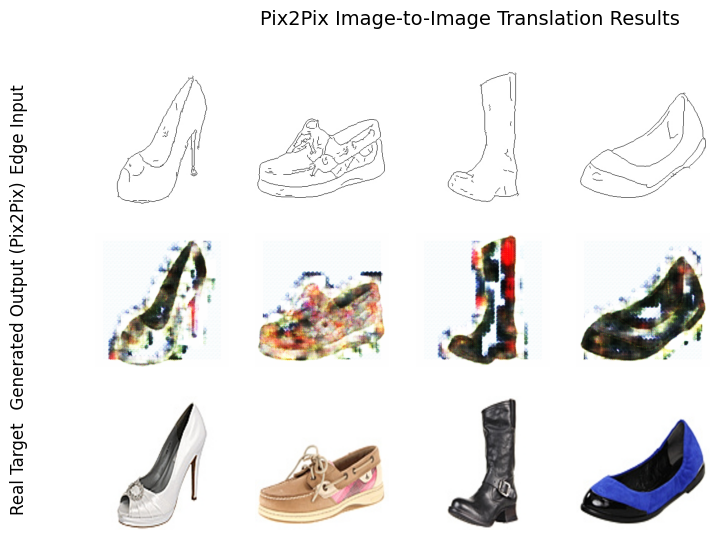

In [30]:
G.eval()

edge, real = next(iter(train_loader))

edge = edge.to(device)

with torch.no_grad():
    fake = G(edge)

# Denormalize
edge = (edge+1)/2
fake = (fake+1)/2
real = (real+1)/2

# Move to CPU
edge = edge.cpu()
fake = fake.cpu()
real = real.cpu()

# Create figure
fig = plt.figure(figsize=(10,6))

# Row labels
fig.text(0.04, 0.75, "        Edge Input ", fontsize=12, rotation=90, va="center")
fig.text(0.04, 0.50, "          Generated Output (Pix2Pix)         ", fontsize=12, rotation=90, va="center")
fig.text(0.04, 0.25, "Real Target        ", fontsize=12, rotation=90, va="center")

# Show images
num_images = edge.size(0)

for i in range(num_images):

    plt.subplot(3,5,i+1)
    plt.imshow(edge[i].permute(1,2,0))
    plt.axis("off")

    plt.subplot(3,5,i+6)
    plt.imshow(fake[i].permute(1,2,0))
    plt.axis("off")

    plt.subplot(3,5,i+11)
    plt.imshow(real[i].permute(1,2,0))
    plt.axis("off")

plt.suptitle("Pix2Pix Image-to-Image Translation Results", fontsize=14)

plt.show()